In [ ]:
#import os
#import random
#from pathlib import Path
#import shutil
#
## Carpetas de origen
#IMAGES_DIR = Path("C:/Users/USER/Documents/Trabajo/Training_Cedulas2.0 (2)/images")
#LABELS_DIR = Path("C:/Users/USER/Documents/Trabajo/Training_Cedulas2.0 (2)/labels")
#
## Porcentajes de división
#train_ratio = 0.7
#val_ratio = 0.3
#test_ratio = 0.0
#
## Asegurarse de tener imágenes con su .txt correspondiente
#image_files = sorted([f for f in IMAGES_DIR.glob("*.*") if f.suffix in ['.jpg', '.jpeg', '.png']])
#valid_files = [f for f in image_files if (LABELS_DIR / f.with_suffix(".txt").name).exists()]
#
#print(f"Total de imágenes válidas: {len(valid_files)}")
#
## Mezclar aleatoriamente
#random.shuffle(valid_files)
#
## Separar
#n = len(valid_files)
#train_files = valid_files[:int(n * train_ratio)]
#val_files = valid_files[int(n * train_ratio):int(n * (train_ratio + val_ratio))]
#test_files = valid_files[int(n * (train_ratio + val_ratio)):]
#
#splits = {
#    "train": train_files,
#    "val": val_files,
#    "test": test_files,
#}
#
## Crear carpetas destino
#for split in splits:
#    (IMAGES_DIR / split).mkdir(parents=True, exist_ok=True)
#    (LABELS_DIR / split).mkdir(parents=True, exist_ok=True)
#
#    for img_path in splits[split]:
#        label_path = LABELS_DIR / img_path.with_suffix(".txt").name
#        shutil.copy(img_path, IMAGES_DIR / split / img_path.name)
#        shutil.copy(label_path, LABELS_DIR / split / label_path.name)
#
#print("✅ División completada: train / val / test.")


In [ ]:
#import os
#
## Carpetas de etiquetas
#label_dirs = [
#    "E:/Users/Documents/Trabajo/Training_Cedulas2.0 (2)/dataset/labels/train",
#    "E:/Users/Documents/Trabajo/Training_Cedulas2.0 (2)/dataset/labels/val"
#]
#
#for label_dir in label_dirs:
#    for file_name in os.listdir(label_dir):
#        if file_name.endswith(".txt"):
#            file_path = os.path.join(label_dir, file_name)
#
#            with open(file_path, "r") as f:
#                lines = f.readlines()
#
#            new_lines = []
#            for line in lines:
#                if line.startswith("1 ") or line.startswith("2 "):
#                    continue  # Ignorar esta línea
#                # Reemplazos de etiquetas
#                line = line.replace("3 ", "1 ").replace("4 ", "2 ").replace("5 ", "3 ")
#                new_lines.append(line)
#
#            with open(file_path, "w") as f:
#                f.writelines(new_lines)
#


0: 384x640 None27.5ms
Speed: 3.9ms preprocess, 27.5ms inference, 8.0ms postprocess per image at shape (1, 3, 384, 640)
[[     196.09      60.575      29.397      54.422      1.5583]
 [     208.09      85.944      20.085      75.726      1.5669]
 [     133.89      197.76      72.231      17.874   0.0036483]]
89.774864


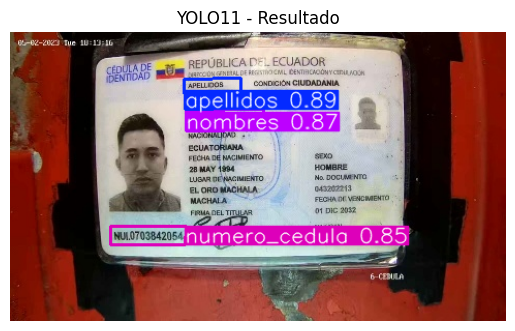

In [ ]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np 
# Cargar el modelo YOLO (puede ser 'yolov8n.pt' o tu modelo personalizado)
#model = YOLO("E:/Users/Documents/Trabajo/MiCasitaCIDetection/best_v8n_obb.pt")  # Cambia por "runs/detect/train/weights/best.pt"
model = YOLO("E:/Users/Documents/Trabajo/MiCasitaCIDetection/best_v11n_obb.pt")  # Cambia por "runs/detect/train/weights/best.pt"

# Tipo de fuente
SOURCE_TYPE = "image"  # Opciones: "image"
SOURCE_PATH = "C:/Users/USER/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Otros/ImagenCedula_0iJH6H4.jpg"  # Ruta de la imagen
#SOURCE_PATH = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Otros/ImagenCedula_21yKmKp.jpg"  # Ruta de la imagen

if SOURCE_TYPE == "image":
    # Cargar imagen con PIL
    image = Image.open(SOURCE_PATH).convert("RGB")#.rotate(90)

    # Realizar inferencia
    results = model(image)

    # Mostrar resultados usando PIL
    for result in results:
        # result.plot() devuelve una imagen NumPy (BGR), la convertimos a RGB para PIL
        img_array = result.plot()[:, :, ::-1]
        data=result.obb.xywhr.cpu().numpy()
        print(data)
        print(np.degrees(data[1][-1]))
        result_image = Image.fromarray(img_array)#.rotate(np.degrees(data[1][-1]))
        # Mostrar usando matplotlib
        plt.imshow(result_image)
        plt.axis('off')
        plt.title("YOLO11 - Resultado")
        plt.show()
